In [1]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from xgboost import XGBClassifier, XGBRegressor
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


In [2]:
breast = pd.read_csv('breast-level_annotations.csv')
columns = ['study_id','series_id', 'laterality', 'view_position',
       'breast_birads', 'breast_density']
breast = breast[columns]
breast['breast_density'] = breast['breast_density'].map({'DENSITY A':1 , 'DENSITY B': 2 , 'DENSITY C' : 3 , 'DENSITY D': 4})

# Convert BI-RADS to numeric (int)
breast['breast_birads'] = (
    breast['breast_birads']
    .str.replace('BI-RADS ', '', regex=False)  # Remove prefix
    .astype(int)  # Convert to integer
)

# Collapse to breast-level (one row per study_id + laterality)
breast = breast.groupby(['study_id','series_id', 'laterality'], as_index=False).agg({
    'breast_birads': 'max',
    'breast_density': 'max'
})

breast.head()

,study_id,series_id,laterality,breast_birads,breast_density
0,0025a5dc99fd5c742026f0b2b030d3e9,47d59b788d64eecab165d97471c4131a,L,1,3
1,0025a5dc99fd5c742026f0b2b030d3e9,47d59b788d64eecab165d97471c4131a,R,1,3
2,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,ff5d6ba6e303628092020e897fcbc9b1,L,2,3
3,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,ff5d6ba6e303628092020e897fcbc9b1,R,2,3
4,0034765af074f93ed33d5e8399355caf,91de7075b7eb54cc4fc959ef67b9df56,L,2,3


In [3]:
find=pd.read_csv('finding_annotations.csv')
find.head()
columns = ['study_id', 'series_id', 'laterality', 
        'breast_birads', 'breast_density', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax']
find = find[columns]

# birads to int
find['breast_birads'] = (
    find['breast_birads']
    .str.replace('BI-RADS ', '', regex=False)  # Remove prefix
    .astype(float)  # Convert to integer
)
find['finding_birads'] = (
    find['finding_birads']
    .str.replace('BI-RADS ', '', regex=False)
    .astype(float)
)

# casting to int
find['breast_density'] = find['breast_density'].map({'DENSITY A':1 , 'DENSITY B': 2 , 'DENSITY C' : 3 , 'DENSITY D': 4})


# 2. Calculate lesion size
find['width']  = find['xmax'] - find['xmin']
find['height'] = find['ymax'] - find['ymin']
find['area']   = find['width'] * find['height']


# Aggregate to breast-level
find = (
    find.groupby(['study_id','series_id', 'laterality'], as_index=False)
        .agg(
            breast_birads=('breast_birads', 'max'),          # highest BI-RADS across views
            breast_density=('breast_density', 'max'),        # highest density across views
            findings_count=('finding_birads', lambda x: x.notna().sum()),  # count only valid findings
            mean_width=('width', 'mean'),
            max_width=('width', 'max'),
            mean_height=('height', 'mean'),
            max_height=('height', 'max'),
            mean_area=('area', 'mean'),
            max_area=('area', 'max')
        )
)

print(find.shape)
find.head()


(978, 12)


,study_id,series_id,laterality,breast_birads,breast_density,findings_count,mean_width,max_width,mean_height,max_height,mean_area,max_area
0,003700f3c960e0b9bca2b8437c3dbf05,a729825009af3184f46ef773e3d93d87,L,4.0,3.0,2,59.369019,60.053009,58.139954,65.059937,3456.445210,3907.044982
1,008b8e61390fcb4c0873258c15b0a53a,bd0e137f3fc5b069db934797924d7d99,R,4.0,3.0,2,424.325073,443.100098,467.834472,476.609008,198678.638727,211185.498374
2,00a369b4ec1e5e0ff34e6bd838e5f2d6,0da08b11f65b222c697727fd32ab068e,L,3.0,3.0,1,288.879990,288.879990,325.830079,325.830079,94125.789833,94125.789833
3,012e0595adba5173b6e60a97f9e84b6e,a80a25f4bb029ba92a3ae1c6babcc767,L,3.0,3.0,2,428.645996,443.984009,523.434998,568.439942,225058.602514,252378.244211
4,012e0595adba5173b6e60a97f9e84b6e,a80a25f4bb029ba92a3ae1c6babcc767,R,3.0,3.0,2,374.260010,376.979980,422.390075,444.460083,158023.683900,165134.716572


In [4]:
meta = pd.read_csv('metadata.csv')
meta = meta.rename(columns={
    "Series Instance UID": "series_id",
    "Patient's Age": "age"
})

In [5]:
# Merge on study_id + laterality
df = pd.merge(breast, find, on=['study_id', 'laterality'], how='inner')

meta_agg = meta.groupby('series_id', as_index=False)['age'].max()
df = pd.merge(df, meta_agg, left_on='series_id_x', right_on='series_id', how='left')






# Check shape and sample
print("Merged shape:", df.shape)
# Map laterality: L -> 0, R -> 1
df['laterality'] = df['laterality'].map({'L': 0, 'R': 1})

df = df.drop(columns=['study_id', 'breast_birads_y','breast_density_y'])
df = df.rename(columns={
     'breast_birads_x': 'breast_birads',
    'breast_density_x': 'breast_density'
})
# Merge BI-RADS 2 into BI-RADS 3, then re-map
df['breast_birads'] = df['breast_birads'].replace({2: 3})
df['breast_birads'] = df['breast_birads'].replace({4: 5})
# as only 8 cases ofbirads 2
df['breast_birads'] = df['breast_birads'].map({3:0,5:1})

# ---------------------------------------------------------
# Remove trailing 'Y', leading zeros, and convert to numeric
df['age'] = pd.to_numeric(
    df['age'].astype(str).str.rstrip('Y').str.lstrip('0'),
    errors='coerce'
)

# Now drop rows with NaN ages
df = df.dropna(subset=['age'])

# Now it's safe: convert to int
df['age'] = df['age'].astype(int)


#-----------------------------------------------------------

# 4. Basic ratios & per-finding metrics
df['width_ratio']          = df['max_width']  / df['mean_width']
df['height_ratio']         = df['max_height'] / df['mean_height']
df['area_ratio']           = df['max_area']   / df['mean_area']
df['aspect_ratio']         = df['mean_width'] / df['mean_height']
df['lesion_density_ratio'] = df['findings_count'] / df['breast_density']
df['area_per_finding']     = df['mean_area'] / (df['findings_count'] + 1e-6)

# 5. Count & density interactions (scaled)
df['count_x_mean_area']    = (df['findings_count'] * df['mean_area'])  / 1000
df['count_x_max_area']     = (df['findings_count'] * df['max_area'])   / 1000
df['density_x_mean_area']  = (df['breast_density'] * df['mean_area'])  / 1000
df['density_x_max_area']   = (df['breast_density'] * df['max_area'])   / 1000

# 6. Age-based interactions & non-linear
df['age_x_density']        = df['age'] * df['lesion_density_ratio']
df['age_x_mean_area']      = (df['age'] * df['mean_area']) / 1000
df['age_x_aspect']         = df['age'] * df['aspect_ratio']
df['age_squared']          = df['age'] ** 2
df['log_age']              = np.log1p(df['age'])
df['age_group']            = pd.cut(df['age'], bins=[0, 40, 55, 100], labels=[0, 1, 2]).astype(int)

# 7. Area variability & shape complexity
df['area_variability']     = df['max_area']  - df['mean_area']
df['area_var_ratio']       = df['area_variability'] / (df['mean_area'] + 1)
df['shape_complexity']     = df['width_ratio'] * df['height_ratio'] * df['aspect_ratio']
df['elongation']           = np.maximum(df['width_ratio'], df['height_ratio'])
df['size_consistency']     = 1 / (df['width_ratio'] + df['height_ratio'] + df['area_ratio'])

# 8. Clinical risk features
df['birads_age_risk']      = (df['breast_birads'] * df['age']) / 50
df['density_age_interaction']= df['lesion_density_ratio'] * df['age']
df['area_per_age']         = df['mean_area'] / (df['age'] + 1)

# 9. Log transforms
for col in ['mean_area', 'max_area', 'count_x_mean_area', 'count_x_max_area']:
    df[f'log_{col}']      = np.log1p(df[col])

# 10. Select top features for modeling
top_features = [
    'breast_birads',
    'width_ratio',
    'age_x_aspect',
    'log_max_area',
    'area_variability',
    'aspect_ratio',
    'age_x_density',
    'height_ratio',
    'density_x_mean_area',
    'elongation',
    'size_consistency'
]

df = df[top_features]
df.head()

Merged shape: (1001, 17)


,breast_birads,width_ratio,age_x_aspect,log_max_area,area_variability,aspect_ratio,age_x_density,height_ratio,density_x_mean_area,elongation,size_consistency
0,1,1.011521,44.930149,8.270793,450.599772,1.021140,29.333333,1.119023,10.369336,1.119023,0.306663
1,1,1.044247,47.163912,12.260497,12506.859647,0.906998,34.666667,1.018756,596.035916,1.044247,0.319902
2,0,1.000000,43.443256,11.452398,0.000000,0.886597,16.333333,1.000000,282.377369,1.000000,0.333333
3,0,1.035782,39.307666,12.438688,27319.641697,0.818910,32.000000,1.085980,675.175808,1.085980,0.308342
4,0,1.007268,42.530546,12.014523,7111.032672,0.886053,32.000000,1.052250,474.071052,1.052250,0.322111


In [6]:
# feature engineering

X = df.drop(columns=['breast_birads'])
y = df['breast_birads']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
# X and y from your preprocessed features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features for neural net
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.0881  | val_0_accuracy: 0.50218 | val_1_accuracy: 0.52023 |  0:00:00s
epoch 1  | loss: 1.05733 | val_0_accuracy: 0.59942 | val_1_accuracy: 0.62428 |  0:00:01s
epoch 2  | loss: 0.88512 | val_0_accuracy: 0.51959 | val_1_accuracy: 0.46243 |  0:00:01s
epoch 3  | loss: 1.68025 | val_0_accuracy: 0.60668 | val_1_accuracy: 0.56069 |  0:00:02s
epoch 4  | loss: 0.92016 | val_0_accuracy: 0.59507 | val_1_accuracy: 0.60116 |  0:00:03s
epoch 5  | loss: 1.16343 | val_0_accuracy: 0.56023 | val_1_accuracy: 0.54335 |  0:00:03s
epoch 6  | loss: 0.82028 | val_0_accuracy: 0.63135 | val_1_accuracy: 0.60694 |  0:00:04s
epoch 7  | loss: 0.72867 | val_0_accuracy: 0.6328  | val_1_accuracy: 0.6185  |  0:00:05s
epoch 8  | loss: 0.7472  | val_0_accuracy: 0.62119 | val_1_accuracy: 0.59538 |  0:00:05s
epoch 9  | loss: 0.66976 | val_0_accuracy: 0.61974 | val_1_accuracy: 0.53757 |  0:00:06s
epoch 10 | loss: 0.63276 | val_0_accuracy: 0.61829 | val_1_accuracy: 0.63584 |  0:00:07s
epoch 11 | loss: 0.64

c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Trial 1: F1 = 0.6720
Params: {'n_d': 16, 'n_a': 16, 'n_steps': 9, 'gamma': 1.5, 'lambda_sparse': 1e-05, 'lr': 0.03}


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


...

c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.05977 | val_0_accuracy: 0.52104 | val_1_accuracy: 0.52601 |  0:00:00s
epoch 1  | loss: 0.74283 | val_0_accuracy: 0.61248 | val_1_accuracy: 0.55491 |  0:00:01s
epoch 2  | loss: 0.74015 | val_0_accuracy: 0.57475 | val_1_accuracy: 0.58382 |  0:00:01s
epoch 3  | loss: 0.64241 | val_0_accuracy: 0.66909 | val_1_accuracy: 0.6185  |  0:00:02s
epoch 4  | loss: 0.63708 | val_0_accuracy: 0.61248 | val_1_accuracy: 0.59538 |  0:00:02s
epoch 5  | loss: 0.62349 | val_0_accuracy: 0.61829 | val_1_accuracy: 0.57225 |  0:00:03s
epoch 6  | loss: 0.64746 | val_0_accuracy: 0.627   | val_1_accuracy: 0.59538 |  0:00:04s
epoch 7  | loss: 0.6345  | val_0_accuracy: 0.65312 | val_1_accuracy: 0.6185  |  0:00:04s
epoch 8  | loss: 0.63312 | val_0_accuracy: 0.64441 | val_1_accuracy: 0.56069 |  0:00:05s
epoch 9  | loss: 0.63779 | val_0_accuracy: 0.64006 | val_1_accuracy: 0.62428 |  0:00:05s
epoch 10 | loss: 0.61224 | val_0_accuracy: 0.64151 | val_1_accuracy: 0.61272 |  0:00:06s
epoch 11 | loss: 0.61

c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.28384 | val_0_accuracy: 0.54427 | val_1_accuracy: 0.57225 |  0:00:00s
epoch 1  | loss: 1.01281 | val_0_accuracy: 0.60668 | val_1_accuracy: 0.6185  |  0:00:00s
epoch 2  | loss: 0.85285 | val_0_accuracy: 0.61974 | val_1_accuracy: 0.62428 |  0:00:01s
epoch 3  | loss: 0.84271 | val_0_accuracy: 0.6299  | val_1_accuracy: 0.63006 |  0:00:01s
epoch 4  | loss: 0.7986  | val_0_accuracy: 0.61684 | val_1_accuracy: 0.6763  |  0:00:02s
epoch 5  | loss: 0.81575 | val_0_accuracy: 0.62845 | val_1_accuracy: 0.65318 |  0:00:02s
epoch 6  | loss: 0.79812 | val_0_accuracy: 0.62845 | val_1_accuracy: 0.60694 |  0:00:02s
epoch 7  | loss: 0.7162  | val_0_accuracy: 0.61248 | val_1_accuracy: 0.63006 |  0:00:03s
epoch 8  | loss: 0.74309 | val_0_accuracy: 0.62554 | val_1_accuracy: 0.60116 |  0:00:03s
epoch 9  | loss: 0.69092 | val_0_accuracy: 0.6328  | val_1_accuracy: 0.60116 |  0:00:04s
epoch 10 | loss: 0.70555 | val_0_accuracy: 0.6328  | val_1_accuracy: 0.60116 |  0:00:04s
epoch 11 | loss: 0.69

c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


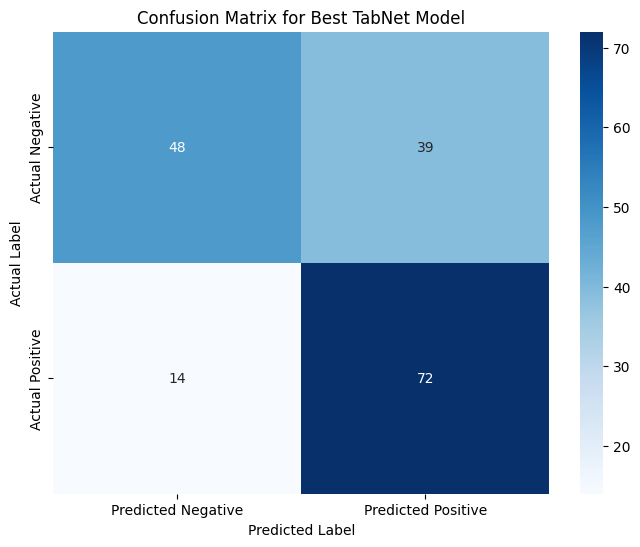

In [7]:
import numpy as np
import pandas as pd
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
from sklearn.utils.class_weight import compute_class_weight
import torch

import random
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Function to run one tabnet training & evaluation
def evaluate_tabnet(hparams):
    tabnet = TabNetClassifier(
        n_d=hparams['n_d'],
        n_a=hparams['n_a'],
        n_steps=hparams['n_steps'],
        gamma=hparams['gamma'],
        lambda_sparse=hparams['lambda_sparse'],
        seed=42,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=hparams['lr'])
    )
    tabnet.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        max_epochs=200,
        patience=100,
        batch_size=128, virtual_batch_size=32,
        eval_metric=['accuracy']
    )
    test_probs = tabnet.predict_proba(X_test)[:, 1]
    # Tune threshold each trial for best F1
    precision, recall, pr_thresholds = precision_recall_curve(y_test, test_probs)
    f1_scores = 2 * precision * recall / (precision + recall)
    best_idx = np.nanargmax(f1_scores)
    optimal_threshold = pr_thresholds[best_idx]
    preds = (test_probs >= optimal_threshold).astype(int)
    score = f1_score(y_test, preds)
    return score, hparams, classification_report(y_test, preds), confusion_matrix(y_test, preds), tabnet

# Hyperparameter grid
param_grid = {
    'n_d': [16, 32, 64, 128],
    'n_a': [16, 32, 64, 128],
    'n_steps': [5, 7, 9, 10],
    'gamma': [1.0, 1.5, 2.0, 2.5],
    'lambda_sparse': [0, 1e-5, 1e-4, 1e-3],
    'lr': [0.005, 0.01, 0.02, 0.03]
}

# Run randomized search
best_score = -1
best_result = None
best_model = None  
for i in range(15):  # Try 15 random combinations
    hparams = {k: random.choice(v) for k, v in param_grid.items()}
    score, used_params, report, conf_mat, model_instance = evaluate_tabnet(hparams)
    print(f'\nTrial {i+1}: F1 = {score:.4f}')
    print('Params:', used_params)
    if score > best_score:
        best_score = score
        best_result = (used_params, report, conf_mat)
        best_model = model_instance  # Save the best model


print("\nBest hyperparameters:")
print(best_result[0])
print("\nClassification Report for Best Model:")
print(best_result[1])
# print(best_result)
# Extract the confusion matrix of the best model
best_conf_mat = best_result[2]

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(best_conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Best TabNet Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()









In [8]:
import numpy as np
import pandas as pd
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
from sklearn.utils.class_weight import compute_class_weight
import torch

import random
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Function to run one tabnet training & evaluation
def evaluate_tabnet(hparams):
    tabnet = TabNetClassifier(
        n_d=hparams['n_d'],
        n_a=hparams['n_a'],
        n_steps=hparams['n_steps'],
        gamma=hparams['gamma'],
        lambda_sparse=hparams['lambda_sparse'],
        seed=42,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=hparams['lr'])
    )
    tabnet.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        max_epochs=200,
        patience=200,
        batch_size=128, virtual_batch_size=32,
        eval_metric=['accuracy']
    )
    test_probs = tabnet.predict_proba(X_test)[:, 1]
    # Tune threshold each trial for best F1
    precision, recall, pr_thresholds = precision_recall_curve(y_test, test_probs)
    f1_scores = 2 * precision * recall / (precision + recall)
    best_idx = np.nanargmax(f1_scores)
    optimal_threshold = pr_thresholds[best_idx]
    preds = (test_probs >= optimal_threshold).astype(int)
    score = f1_score(y_test, preds)
    return score, hparams, classification_report(y_test, preds), confusion_matrix(y_test, preds)

# Hyperparameter grid
param_grid = {
    'n_d': [8, 16, 24],
    'n_a': [8, 16, 24],
    'n_steps': [ 8, 9, 10],
    'gamma': [1.8,  2.0, 2.2],
    'lambda_sparse': [0.0005, 0.001, 0.002],
    'lr': [0.025, 0.03, 0.035]
}

# Run randomized search
best_score = -1
best_result = None
for i in range(15):  # Try 15 random combinations
    hparams = {k: random.choice(v) for k, v in param_grid.items()}
    score, used_params, report, conf_mat = evaluate_tabnet(hparams)
    print(f'\nTrial {i+1}: F1 = {score:.4f}')
    print('Params:', used_params)
    if score > best_score:
        best_score = score
        best_result = (used_params, report, conf_mat)

print("\nBest hyperparameters:")
print(best_result[0])
print(best_result[1])
print(best_result)




c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 2.33473 | val_0_accuracy: 0.5225  | val_1_accuracy: 0.50867 |  0:00:00s
epoch 1  | loss: 1.50254 | val_0_accuracy: 0.62554 | val_1_accuracy: 0.60116 |  0:00:01s
epoch 2  | loss: 1.36139 | val_0_accuracy: 0.52395 | val_1_accuracy: 0.53757 |  0:00:02s
epoch 3  | loss: 1.21105 | val_0_accuracy: 0.62845 | val_1_accuracy: 0.53179 |  0:00:02s
epoch 4  | loss: 0.87085 | val_0_accuracy: 0.58345 | val_1_accuracy: 0.55491 |  0:00:03s
epoch 5  | loss: 0.90248 | val_0_accuracy: 0.58345 | val_1_accuracy: 0.58382 |  0:00:04s
epoch 6  | loss: 0.81219 | val_0_accuracy: 0.59071 | val_1_accuracy: 0.5896  |  0:00:04s
epoch 7  | loss: 0.71854 | val_0_accuracy: 0.5762  | val_1_accuracy: 0.57225 |  0:00:05s
epoch 8  | loss: 0.75029 | val_0_accuracy: 0.55878 | val_1_accuracy: 0.54913 |  0:00:06s
epoch 9  | loss: 0.7116  | val_0_accuracy: 0.63135 | val_1_accuracy: 0.65896 |  0:00:06s
epoch 10 | loss: 0.70068 | val_0_accuracy: 0.61974 | val_1_accuracy: 0.59538 |  0:00:07s
epoch 11 | loss: 0.66

c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Trial 1: F1 = 0.6857
Params: {'n_d': 24, 'n_a': 16, 'n_steps': 9, 'gamma': 2.0, 'lambda_sparse': 0.002, 'lr': 0.03}


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


...


Trial 14: F1 = 0.6842
Params: {'n_d': 8, 'n_a': 24, 'n_steps': 8, 'gamma': 2.0, 'lambda_sparse': 0.0005, 'lr': 0.025}


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.18344 | val_0_accuracy: 0.49202 | val_1_accuracy: 0.43931 |  0:00:00s
epoch 1  | loss: 0.92931 | val_0_accuracy: 0.55588 | val_1_accuracy: 0.46821 |  0:00:01s
epoch 2  | loss: 0.81519 | val_0_accuracy: 0.55007 | val_1_accuracy: 0.54335 |  0:00:02s
epoch 3  | loss: 0.81091 | val_0_accuracy: 0.58491 | val_1_accuracy: 0.52023 |  0:00:03s
epoch 4  | loss: 0.73109 | val_0_accuracy: 0.65312 | val_1_accuracy: 0.6185  |  0:00:04s
epoch 5  | loss: 0.71146 | val_0_accuracy: 0.61393 | val_1_accuracy: 0.57803 |  0:00:05s
epoch 6  | loss: 0.69707 | val_0_accuracy: 0.6357  | val_1_accuracy: 0.63006 |  0:00:06s
epoch 7  | loss: 0.67515 | val_0_accuracy: 0.62845 | val_1_accuracy: 0.58382 |  0:00:06s
epoch 8  | loss: 0.66044 | val_0_accuracy: 0.59216 | val_1_accuracy: 0.57225 |  0:00:07s
epoch 9  | loss: 0.63256 | val_0_accuracy: 0.64151 | val_1_accuracy: 0.63584 |  0:00:08s
epoch 10 | loss: 0.62429 | val_0_accuracy: 0.64296 | val_1_accuracy: 0.57225 |  0:00:09s
epoch 11 | loss: 0.62

c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Trial 15: F1 = 0.6761
Params: {'n_d': 8, 'n_a': 24, 'n_steps': 10, 'gamma': 2.2, 'lambda_sparse': 0.0005, 'lr': 0.03}

Best hyperparameters:
{'n_d': 8, 'n_a': 24, 'n_steps': 10, 'gamma': 2.2, 'lambda_sparse': 0.001, 'lr': 0.03}
              precision    recall  f1-score   support

           0       0.80      0.59      0.68        87
           1       0.67      0.85      0.75        86

    accuracy                           0.72       173
   macro avg       0.73      0.72      0.71       173
weighted avg       0.73      0.72      0.71       173

({'n_d': 8, 'n_a': 24, 'n_steps': 10, 'gamma': 2.2, 'lambda_sparse': 0.001, 'lr': 0.03}, '              precision    recall  f1-score   support\n\n           0       0.80      0.59      0.68        87\n           1       0.67      0.85      0.75        86\n\n    accuracy                           0.72       173\n   macro avg       0.73      0.72      0.71       173\nweighted avg       0.73      0.72      0.71       173\n', array([[51, 36],


In [9]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
import numpy as np

# Define the best hyperparameters explicitly
best_params = {
    'n_d': 16,
    'n_a': 16,
    'n_steps': 9,
    'gamma': 2.0,
    'lambda_sparse': 0.001,
    'lr': 0.03
}

# Initialize the TabNet model with these parameters
model = TabNetClassifier(
    n_d=best_params['n_d'],
    n_a=best_params['n_a'],
    n_steps=best_params['n_steps'],
    gamma=best_params['gamma'],
    lambda_sparse=best_params['lambda_sparse'],
    seed=42,
    optimizer_params=dict(lr=best_params['lr'])
)

# Retrain on full training data
model.fit(
    X_train, y_train,
    max_epochs=200,
    patience=200,
    batch_size=128,
    virtual_batch_size=32,
    eval_metric=['accuracy'],
    eval_set=[(X_train, y_train)]
)

# Predict probabilities on test set
test_probs = model.predict_proba(X_test)[:, 1]


optimal_threshold = 0.5
test_preds = (test_probs >= optimal_threshold).astype(int)

# Evaluate results
print("Classification Report:")
print(classification_report(y_test, test_preds, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, test_preds))

print("Test F1 Score:", f1_score(y_test, test_preds))


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.00995 | val_0_accuracy: 0.54136 |  0:00:00s
epoch 1  | loss: 0.78676 | val_0_accuracy: 0.56023 |  0:00:00s
epoch 2  | loss: 0.70632 | val_0_accuracy: 0.55588 |  0:00:01s
epoch 3  | loss: 0.71653 | val_0_accuracy: 0.60813 |  0:00:01s
epoch 4  | loss: 0.72497 | val_0_accuracy: 0.61393 |  0:00:02s
epoch 5  | loss: 0.83075 | val_0_accuracy: 0.67344 |  0:00:02s
epoch 6  | loss: 0.71458 | val_0_accuracy: 0.57039 |  0:00:03s
epoch 7  | loss: 0.68157 | val_0_accuracy: 0.6328  |  0:00:04s
epoch 8  | loss: 0.65044 | val_0_accuracy: 0.59071 |  0:00:04s
epoch 9  | loss: 0.67495 | val_0_accuracy: 0.61103 |  0:00:04s
epoch 10 | loss: 0.62578 | val_0_accuracy: 0.62554 |  0:00:05s
epoch 11 | loss: 0.65992 | val_0_accuracy: 0.6357  |  0:00:05s
epoch 12 | loss: 0.63647 | val_0_accuracy: 0.61974 |  0:00:06s
epoch 13 | loss: 0.61575 | val_0_accuracy: 0.63135 |  0:00:06s
epoch 14 | loss: 0.62631 | val_0_accuracy: 0.64731 |  0:00:07s
epoch 15 | loss: 0.64525 | val_0_accuracy: 0.59797 |  0

c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
